# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [58]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [59]:
df=pd.read_csv("cleaned_aviation_data.csv")
df.head()

/var/folders/bq/4m5y4fjn1t1_fpdlg7fvg6t80000gn/T/ipykernel_3210/3935639362.py:1: DtypeWarning: Columns (0,6,7,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("cleaned_aviation_data.csv")


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,Total.Passengers,Fatality.Rate,Destroyed,Make_clean,Aircraft_Type
0,20001214X42040,Accident,LAX83LA093,1983-01-01,"ARROYO GRANDE, CA",United States,NaN,NaN,NaN,NaN,...,1.0,vmc,landing,Probable Cause,NaN,2.0,0.0,0.0,other,other_ax-6
1,20001214X42095,Accident,SEA83LA036,1983-01-01,"NEWPORT, OR",United States,NaN,NaN,ONP,NEWPORT MUNICIPAL,...,3.0,vmc,approach,Probable Cause,NaN,4.0,0.0,0.0,cessna,cessna_182p
2,20001214X42067,Accident,MKC83LA056,1983-01-01,"WOODBINE, IA",United States,NaN,NaN,3YR,MUNICIPAL,...,2.0,vmc,landing,Probable Cause,NaN,2.0,0.0,0.0,cessna,cessna_182rg
3,20001214X42063,Accident,MKC83LA050,1983-01-01,"MARYVILLE, MO",United States,NaN,NaN,78Y,RANKIN,...,1.0,vmc,takeoff,Probable Cause,NaN,1.0,0.0,0.0,cessna,cessna_182p
4,20001214X42018,Accident,LAX83FUG11,1983-01-01,"UPLAND, CA",United States,NaN,NaN,CCB,CABLE,...,0.0,vmc,approach,Probable Cause,NaN,2.0,0.0,0.0,piper,piper_pa-28r-200


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [60]:
df["Aircraft_size"]=df["Total.Passengers"].apply(lambda x: "small" if x<20 else "Large")
df[["Total.Passengers","Aircraft_size"]].head()

,Total.Passengers,Aircraft_size
0,2.0,small
1,4.0,small
2,2.0,small
3,1.0,small
4,2.0,small


In [61]:
df.groupby("Aircraft_size")["Fatality.Rate"].mean()

Aircraft_size
Large    0.135158
small    0.222809
Name: Fatality.Rate, dtype: float64

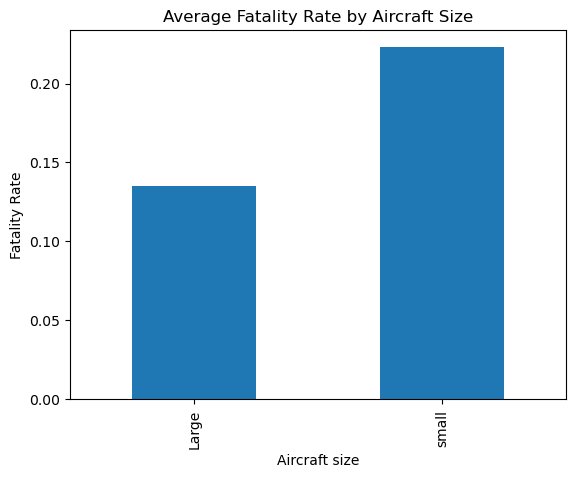

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
df.groupby("Aircraft_size")["Fatality.Rate"].mean().plot(kind="bar")
plt.ylabel("Fatality Rate")
plt.xlabel("Aircraft size")
plt.title("Average Fatality Rate by Aircraft Size")
plt.show()

Smaller aircrafts have a higher  average fatality rates compared to large aircraft.

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [63]:
small_makes=df[df["Aircraft_size"]=="small"].groupby("Make_clean")["Fatality.Rate"].mean().sort_values().head(15)
large_makes=df[df["Aircraft_size"]=="Large"].groupby("Make_clean")["Fatality.Rate"].mean().sort_values().head(15)

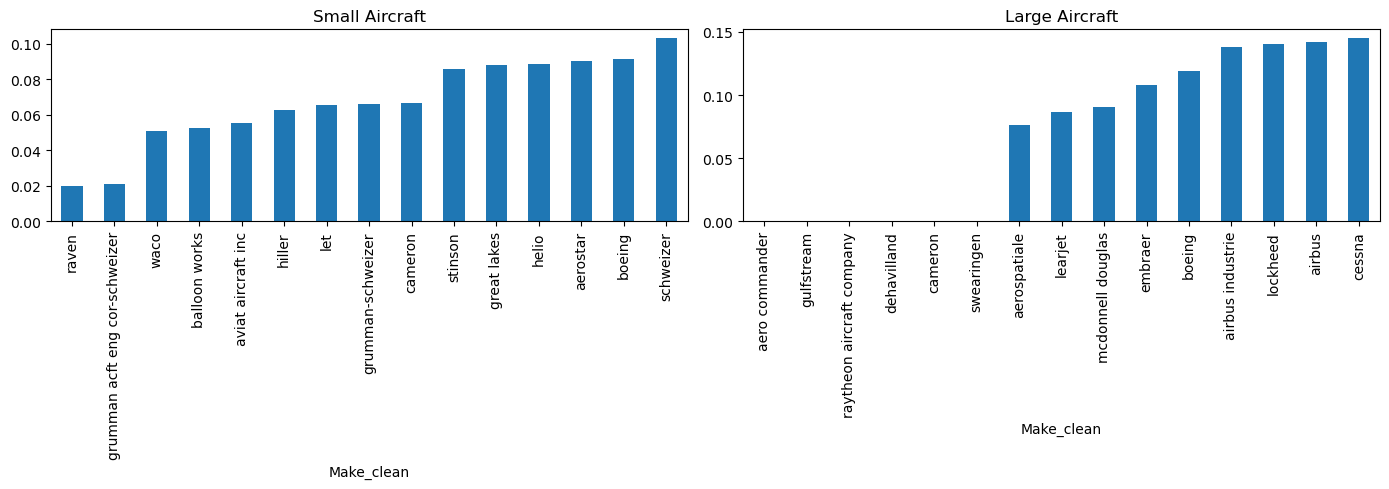

In [64]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
small_makes.plot(kind="bar", ax=axes[0], title="Small Aircraft")
large_makes.plot(kind="bar", ax=axes[1], title="Large Aircraft")
plt.tight_layout()
plt.show()

The analysis compares the safest aircraft manufacturers for both small and large aircrafts based on mean fatality rate

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [65]:
top10_small=(df[df["Aircraft_size"]=="small"].groupby("Make_clean")["Fatality.Rate"].mean().sort_values().head(10)).index


In [66]:
small_df=df[(df["Aircraft_size"]=="small") & (df["Make_clean"].isin(top10_small))]

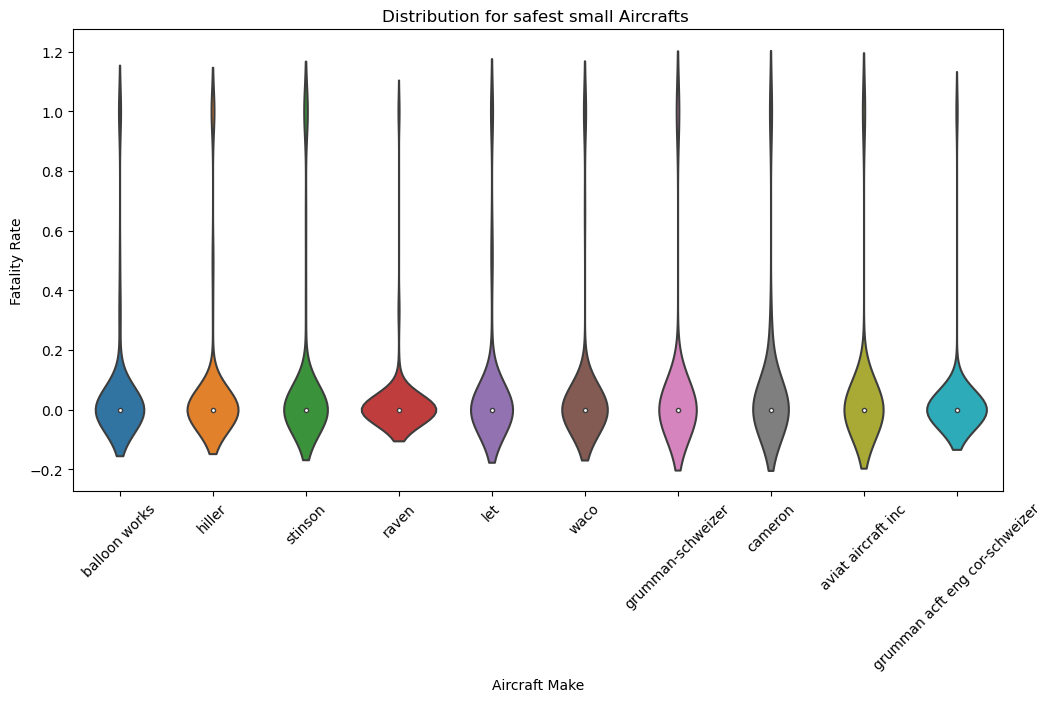

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.violinplot(data=small_df, x="Make_clean", y="Fatality.Rate")
plt.xticks(rotation=45)
plt.title("Distribution for safest small Aircrafts ")
plt.xlabel("Aircraft Make")
plt.ylabel("Fatality Rate")
plt.show()

The violin represents the distribution of fatality rates among the small safest aircrafts.

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [68]:
top10_large=(df[df["Aircraft_size"]=="Large"].groupby("Make_clean")["Fatality.Rate"].mean().sort_values().head(10)).index

In [69]:
large_df=df[(df["Aircraft_size"]=="Large") & (df["Make_clean"].isin(top10_large))]

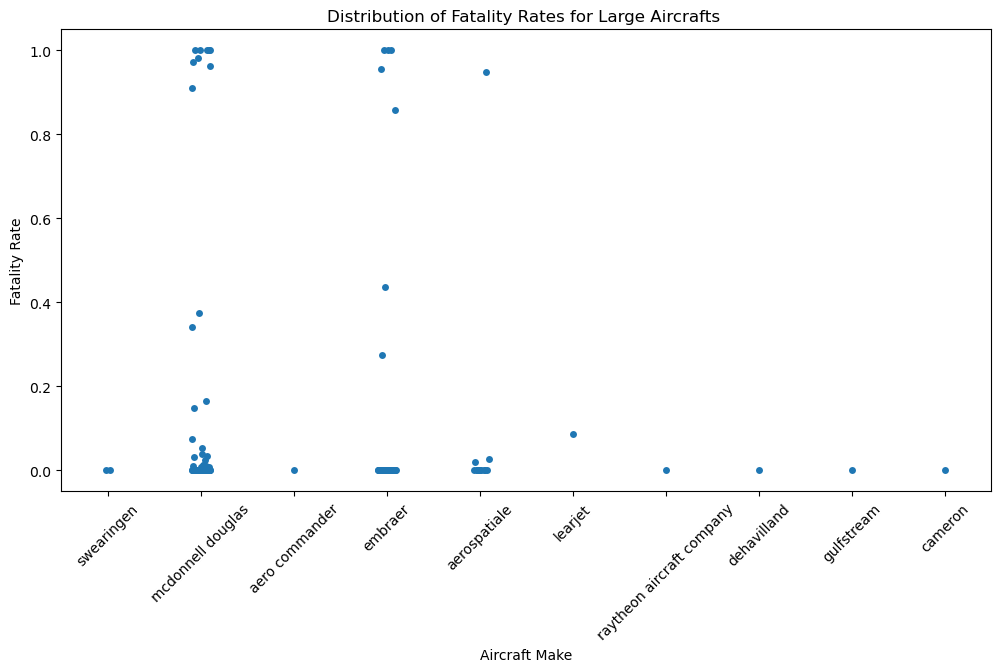

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.stripplot(data=large_df, x="Make_clean", y="Fatality.Rate", jitter=True)
plt.xticks(rotation=45)
plt.title("Distribution of Fatality Rates for Large Aircrafts ")
plt.xlabel("Aircraft Make")
plt.ylabel("Fatality Rate")
plt.show()

In [71]:
The strio plot shows the distribution of fatality rates among the safest large aircraft makes.

SyntaxError: invalid syntax (1619519349.py, line 1)

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [ ]:
df["Destroyed"]=(df["Aircraft.damage"]=="Destroyed").astype(int)

In [ ]:
small_destroy=df[df["Aircraft_size"]=="small"].groupby("Make_clean")["Destroyed"].mean().sort_values().head(15)
large_destroy=df[df["Aircraft_size"]=="Large"].groupby("Make_clean")["Destroyed"].mean().sort_values().head(15)

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [ ]:
The analysis reveals that small aircrafts generally have higher fatality rates compared to large aircrafts. The distribution of fatality rates for the safest small aircrafts shows a wider range, indicating more variability in safety performance among small aircraft manufacturers. In contrast, the large aircrafts tend to have lower fatality rates with less variability, suggesting that they may be subject to stricter safety regulations and standards.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [ ]:
large_df=df[df["Aircraft_size"]=="Large"]
large_counts=large_df["Make_clean"].value_counts()
valid_large_makes=large_counts[large_counts>=10].index
large_df=large_df[large_df["Make_clean"].isin(valid_large_makes)]

In [ ]:
large_means=(large_df.groupby("Make_clean")["Fatality.Rate"].mean().sort_values().head(15))

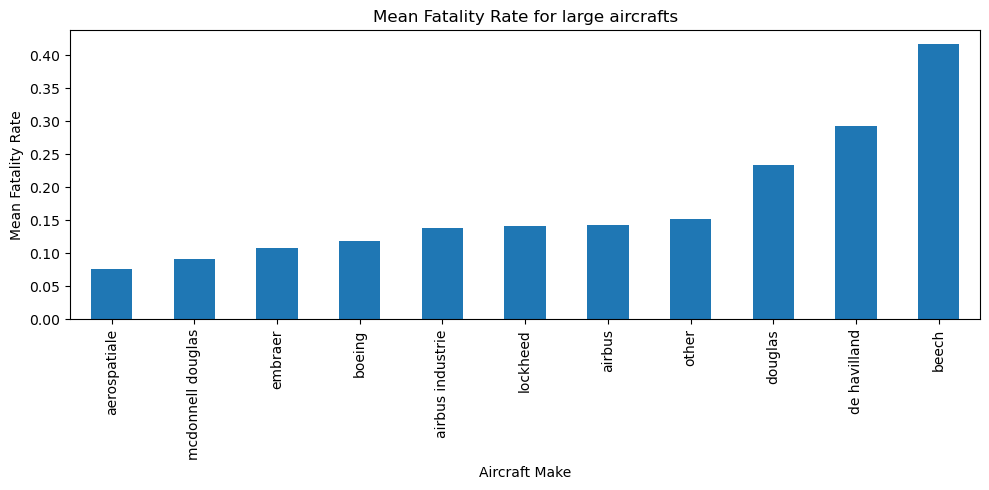

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
large_means.plot(kind="bar",title="Mean Fatality Rate for large aircrafts")
plt.ylabel("Mean Fatality Rate")
plt.xlabel("Aircraft Make")
plt.tight_layout()
plt.show()

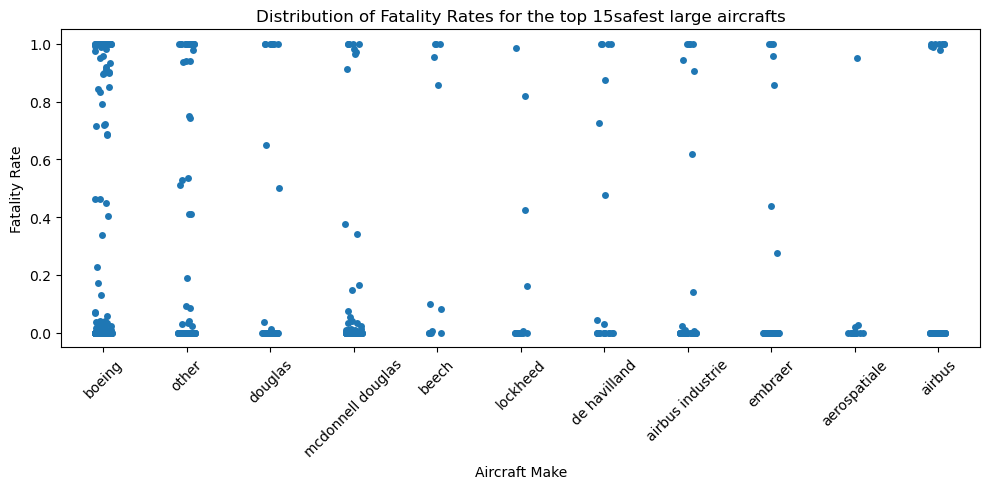

In [ ]:
import seaborn as sns
plt.figure(figsize=(10, 5))

sns.stripplot(data=large_df[large_df["Make_clean"].isin(large_means.index)], x="Make_clean", y="Fatality.Rate")
plt.xticks(rotation=45)
plt.title("Distribution of Fatality Rates for the top 15safest large aircrafts")
plt.xlabel("Aircraft Make")
plt.ylabel("Fatality Rate")
plt.tight_layout()
plt.show()

The analysis shows that large aircraft have lower and consistent fatality rates compared to small aircrafts

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [ ]:
small_df=df[df["Aircraft_size"]=="small"]
small_counts=small_df["Make_clean"].value_counts()
valid_small_makes=small_counts[small_counts>=10].index
small_df=small_df[small_df["Make_clean"].isin(valid_small_makes)]

In [ ]:
small_means=(small_df.groupby("Make_clean")["Fatality.Rate"].mean().sort_values().head(10))

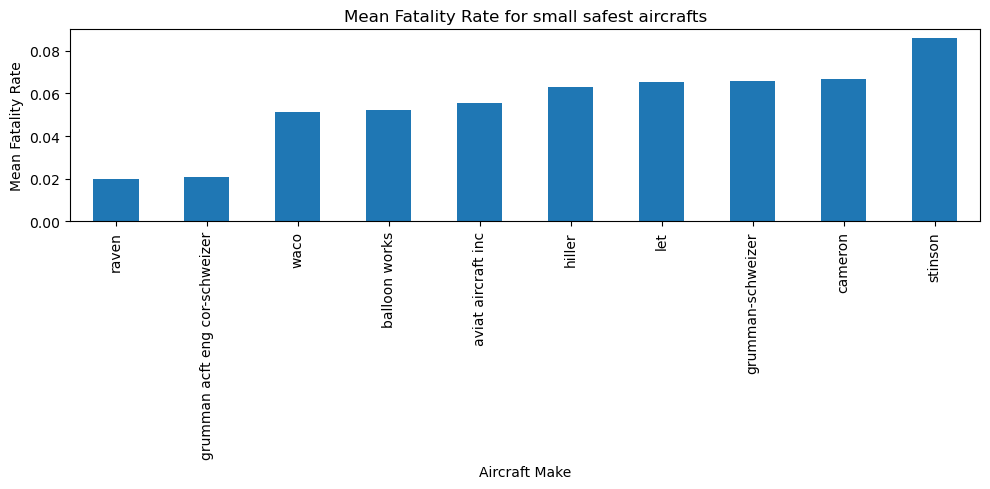

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
small_means.plot(kind="bar", title="Mean Fatality Rate for small safest aircrafts")
plt.ylabel("Mean Fatality Rate")
plt.xlabel("Aircraft Make")
plt.tight_layout()
plt.show()

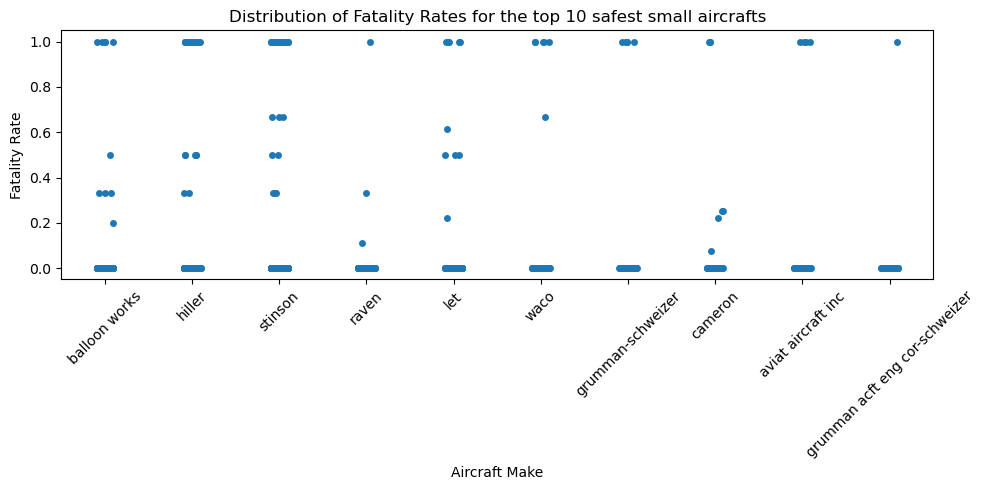

In [ ]:
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.stripplot(data=small_df[small_df["Make_clean"].isin(small_means.index)], x="Make_clean", y="Fatality.Rate")
plt.xticks(rotation=45)
plt.title("Distribution of Fatality Rates for the top 10 safest small aircrafts")
plt.xlabel("Aircraft Make")
plt.ylabel("Fatality Rate")
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

The analysis of airplane types shows clear differences between small and large aircraft in terms of passenger injury outcomes.Large aircraft exhibit lower and more consistent fatal and serious injury fractions. This suggests that larger planes benefit from stronger structural design, better safety systems and stricter regulatory oversight. 
small aircraft display greater variability in injury rates while some manufacturers perform well others show higher fatality fractions...This variability may be due to differences in aircraft design, maintenance standards, and pilot experience in general aviation. findings indicate that large aircraft are safer on average, while safety in small aircraft is more dependent on the specific manufacturer and operating conditions.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

In [ ]:
#WEATHER CONDITIONS
weather_analysis

Weather.Condition
vmc    0.171695
unk    0.597885
imc    0.613989
Name: Fatality.Rate, dtype: float64

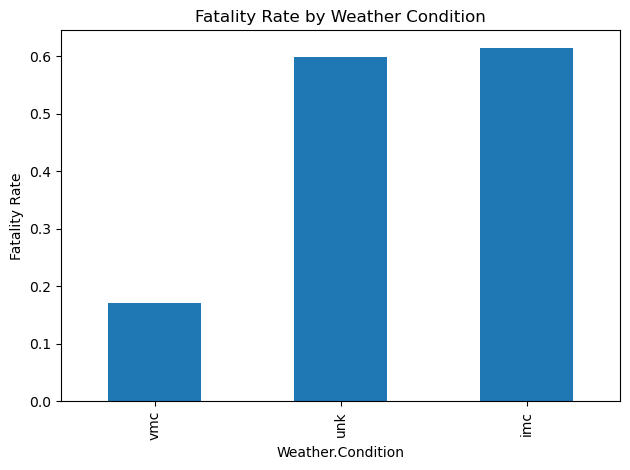

In [ ]:
import matplotlib.pyplot as plt

weather_analysis.plot(kind="bar", title="Fatality Rate by Weather Condition")
plt.ylabel("Fatality Rate")
plt.tight_layout()
plt.show()

Weather conditions have an impact on fatality rates in aviation accidents. Poor weather conditions are associated with higher fatality rates compared to clear weather conditions. This is likely due to reduced visibility, increased pilot workload and more challenging flying conditions.
This highlights the importance of weather monitoring, pilot training and decisionmaking in harsh conditions.

In [ ]:
#ENGINE TYPE
engine_analysis = (df.groupby("Engine.Type")["Fatality.Rate"].mean().sort_values())

engine_analysis


Engine.Type
lr               0.000000
none             0.000000
unk              0.000000
turbo fan        0.137752
reciprocating    0.203369
unknown          0.211909
turbo shaft      0.222231
electric         0.250000
turbo prop       0.303910
turbo jet        0.315950
hybrid rocket    0.500000
Name: Fatality.Rate, dtype: float64

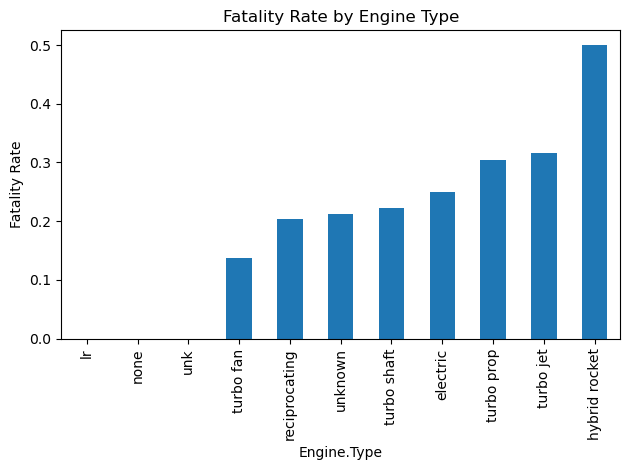

In [ ]:
engine_analysis.plot(kind="bar", title="Fatality Rate by Engine Type")
plt.ylabel("Fatality Rate")
plt.tight_layout()
plt.show()

Engine type influences the severity of aviation accidents. Aircraft with more multiple engine configurations tend to show lower fatality rates compared to simpler engine types.
aircraft with more robust engine configurations demonstrate improved safety outcomes.